# Working with complicated dataset

Your name: Jacob Atanacio

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [2]:
import pandas as pd
import requests
from io import StringIO

url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv'
response = requests.get(url)
lines = response.text.splitlines()

header_line = [l for l in lines if '# Fields:' in l][0]
columns_str = header_line.split('# Fields: ')[1].replace('"', '').strip()
columns = [c.strip() for c in columns_str.split(',') if c.strip()]

data_lines = [l for l in lines if not l.strip().startswith('#') and not l.strip().startswith('"#')]

df = pd.read_csv(StringIO('\n'.join(data_lines)), names=columns, usecols=range(len(columns)))

df = df.drop(columns=['query acc.ver'])
df = df.set_index('subject acc.ver')

display(df.head())

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [11]:
avg_pub = pd.to_numeric(df['publications'], errors='coerce').mean().round()
print(f"The average number of publications is: {avg_pub}")

The average number of publications is: 27.0


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [15]:
df['bonds'] = pd.to_numeric(df['bonds'].astype(str).str.replace(',', ''), errors='coerce')

high_bonds = df[df['bonds'] > 15000].index.tolist()
print("Subject acc.ver with over 15,000 bonds:")
high_bonds

Subject acc.ver with over 15,000 bonds:


['AGK29621.1',
 'AHG32084.1',
 '6G2J_H',
 'YP_002791042.1',
 'AGK29634.1',
 '0806162F',
 'YP_009112408.1',
 'YP_001876469.1',
 'YP_009092269.1',
 'AHG32149.1',
 'YP_009092074.1',
 'YP_009450474.1',
 'YP_004123270.1',
 'YP_009092073.1',
 'AHZ60901.1',
 'YP_004123350.1',
 'YP_009453754.1',
 'ADD46492.1',
 'YP_007025968.1',
 'YP_009453806.1',
 'YP_007024956.1',
 'ASM92364.1',
 'YP_006073044.1',
 'ASM92494.1',
 'ADG95699.1',
 'YP_004891275.1',
 'YP_009166014.1',
 'YP_009538416.1',
 'YP_009414182.1',
 'YP_009178854.1',
 'YP_009414415.1',
 'YP_009353908.1',
 'YP_009093743.1',
 'ABX45285.1',
 'YP_009414156.1',
 'YP_009414363.1']

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

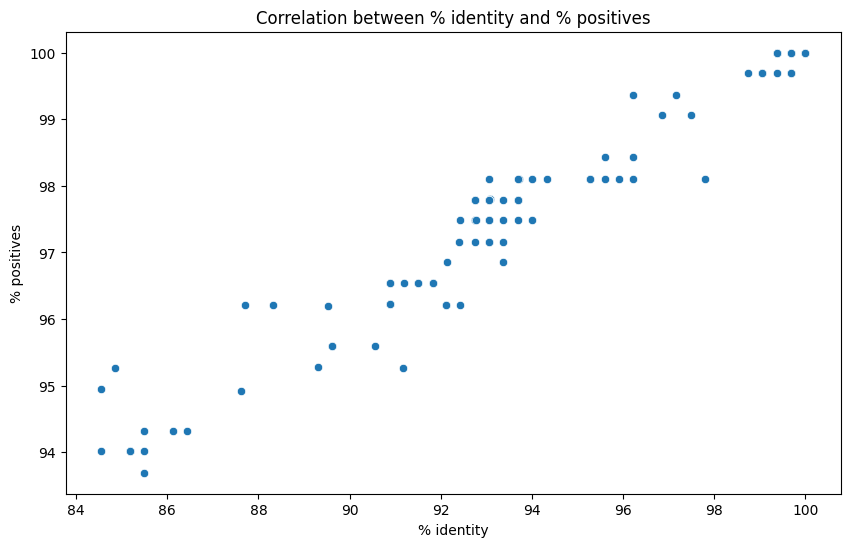

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='% identity', y='% positives')
plt.title('Correlation between % identity and % positives')
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [24]:
source_url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv'
protein_source_df = pd.read_csv(source_url)

protein_source_df = protein_source_df.rename(columns={'Source': 'Protein source'})

df = df.reset_index().merge(
    protein_source_df[['Protein', 'Protein source']],
    left_on='subject acc.ver',
    right_on='Protein',
    how='left'
).drop(columns=['Protein']).set_index('subject acc.ver')

display(df.head())

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3,NaN
